# 1. Introduction, Problem Statement & Objective

Tema: SDGs 3 - Good Health and Well Being

Model: Logistic Regression (From Scratch)

# 2. Dataset Details:
Cervical Cancer Behavior Risk (UCI) = https://archive.ics.uci.edu/dataset/537/cervical+cancer+behavior+risk

# 3. Data Preprocessing & Exploratory Data Analysis

In [381]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [382]:
file_path = 'dataset/sobar-72.csv'
df = pd.read_csv(file_path)
display(df.head())

print("\n--- Informasi Dataset ---")
df.info()

,behavior_sexualRisk,behavior_eating,behavior_personalHygine,intention_aggregation,intention_commitment,attitude_consistency,attitude_spontaneity,norm_significantPerson,norm_fulfillment,perception_vulnerability,perception_severity,motivation_strength,motivation_willingness,socialSupport_emotionality,socialSupport_appreciation,socialSupport_instrumental,empowerment_knowledge,empowerment_abilities,empowerment_desires,ca_cervix
0,10,13,12,4,7,9,10,1,8,7,3,14,8,5,7,12,12,11,8,1
1,10,11,11,10,14,7,7,5,5,4,2,15,13,7,6,5,5,4,4,1
2,10,15,3,2,14,8,10,1,4,7,2,7,3,3,6,11,3,3,15,1
3,10,11,10,10,15,7,7,1,5,4,2,15,13,7,4,4,4,4,4,1
4,8,11,7,8,10,7,8,1,5,3,2,15,5,3,6,12,5,4,7,1



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   behavior_sexualRisk         72 non-null     int64
 1   behavior_eating             72 non-null     int64
 2   behavior_personalHygine     72 non-null     int64
 3   intention_aggregation       72 non-null     int64
 4   intention_commitment        72 non-null     int64
 5   attitude_consistency        72 non-null     int64
 6   attitude_spontaneity        72 non-null     int64
 7   norm_significantPerson      72 non-null     int64
 8   norm_fulfillment            72 non-null     int64
 9   perception_vulnerability    72 non-null     int64
 10  perception_severity         72 non-null     int64
 11  motivation_strength         72 non-null     int64
 12  motivation_willingness      72 non-null     int64
 13  socialSupport_emotionality  72 non-null 

In [383]:
#Error handling

#datatype handling

df.replace('?', np.nan, inplace=True)
df = df.astype(float)

#missing value handling

df.fillna(df.median(), inplace=True)

#normalization handling
X = df.drop(columns=['ca_cervix'])
y = df['ca_cervix']

print(X['behavior_personalHygine'])
X_normalized = (X - X.min()) / (X.max() - X.min())

display(X_normalized.head())

top_7_features = [
    'motivation_strength', 
    'attitude_spontaneity', 
    'empowerment_desires', 
    'perception_vulnerability', 
    'behavior_personalHygine', 
    'empowerment_knowledge', 
    'perception_severity'
]

# 2. Ambil hanya 7 kolom tersebut
X_pruned = X_normalized[top_7_features]

# Cek hasilnya
print(X_pruned.head())

0     12.0
1     11.0
2      3.0
3     10.0
4      7.0
      ... 
67    14.0
68    15.0
69    11.0
70    13.0
71    14.0
Name: behavior_personalHygine, Length: 72, dtype: float64


,behavior_sexualRisk,behavior_eating,behavior_personalHygine,intention_aggregation,intention_commitment,attitude_consistency,attitude_spontaneity,norm_significantPerson,norm_fulfillment,perception_vulnerability,perception_severity,motivation_strength,motivation_willingness,socialSupport_emotionality,socialSupport_appreciation,socialSupport_instrumental,empowerment_knowledge,empowerment_abilities,empowerment_desires
0,1.00,0.833333,0.750000,0.25,0.111111,0.875,1.000000,0.0,0.416667,0.333333,0.125,0.916667,0.416667,0.166667,0.625,0.750000,0.750000,0.666667,0.416667
1,1.00,0.666667,0.666667,1.00,0.888889,0.625,0.500000,1.0,0.166667,0.083333,0.000,1.000000,0.833333,0.333333,0.500,0.166667,0.166667,0.083333,0.083333
2,1.00,1.000000,0.000000,0.00,0.888889,0.750,1.000000,0.0,0.083333,0.333333,0.000,0.333333,0.000000,0.000000,0.500,0.666667,0.000000,0.000000,1.000000
3,1.00,0.666667,0.583333,1.00,1.000000,0.625,0.500000,0.0,0.166667,0.083333,0.000,1.000000,0.833333,0.333333,0.250,0.083333,0.083333,0.083333,0.083333
4,0.75,0.666667,0.333333,0.75,0.444444,0.625,0.666667,0.0,0.166667,0.000000,0.000,1.000000,0.166667,0.000000,0.500,0.750000,0.166667,0.083333,0.333333


   motivation_strength  attitude_spontaneity  empowerment_desires  \
0             0.916667              1.000000             0.416667   
1             1.000000              0.500000             0.083333   
2             0.333333              1.000000             1.000000   
3             1.000000              0.500000             0.083333   
4             1.000000              0.666667             0.333333   

   perception_vulnerability  behavior_personalHygine  empowerment_knowledge  \
0                  0.333333                 0.750000               0.750000   
1                  0.083333                 0.666667               0.166667   
2                  0.333333                 0.000000               0.000000   
3                  0.083333                 0.583333               0.083333   
4                  0.000000                 0.333333               0.166667   

   perception_severity  
0                0.125  
1                0.000  
2                0.000  
3         

In [384]:
# Data Splitting (Training 80% & Testing 20%)
X_array = X_pruned.values
y_array = y.values

np.random.seed(52)
shuffled_indices = np.random.permutation(len(X_array))
X_shuffled = X_array[shuffled_indices]
y_shuffled = y_array[shuffled_indices]

split_idx = int(0.8 * len(X_array))

X_train, X_test = X_shuffled[:split_idx], X_shuffled[split_idx:]
y_train, y_test = y_shuffled[:split_idx], y_shuffled[split_idx:]

print(f"Total Train Data: {len(X_train)}")
print(f"Total Test Data: {len(X_test)}")

Total Train Data: 57
Total Test Data: 15


# 4. Logistic Regression Implementation 

In [385]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.1, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        
        for i in range(self.epochs):
            # z = (X * W) + b
            linear_model = np.dot(X, self.weights) + self.bias
            
    
            y_predicted = self.sigmoid(linear_model)

            #kepelesetan data
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # updating weights
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # saving error value (Binary Cross-Entropy Loss) each 100 itteration
            if i % 100 == 0:
                epsilon = 1e-9 # Mencegah error log(0)
                loss = - (1 / n_samples) * np.sum(y * np.log(y_predicted + epsilon) + (1 - y) * np.log(1 - y_predicted + epsilon))
                self.loss_history.append(loss)

    def predict_probabilities(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    import math

    def compute_loss(y_true, y_pred_probs):
        n = len(y_true)
        epsilon = 1e-15 # Biar nggak error log(0)
        loss = 0
        for i in range(n):
            # Rumus Binary Cross-Entropy
            p = max(epsilon, min(1 - epsilon, y_pred_probs[i]))
            loss += -(y_true[i] * np.log(p) + (1 - y_true[i]) * np.log(1 - p))
        return loss / n

    def predict(self, X, threshold=0.5):
        y_predicted = self.predict_probabilities(X)
        return np.array([1 if i > threshold else 0 for i in y_predicted])

Training Process Finished
Training Process Finished 
Model Guess Result on Testing Data: [1 0 1 0 1 0 0 0 0 0 0 0 0 1 0]
Original Answer from Testing Data  : [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
Model loss history (every 100 epochs): [np.float64(0.6931471785599453), np.float64(0.4326651570013347), np.float64(0.36860419683089485), np.float64(0.32784330213698964), np.float64(0.29963231693711845), np.float64(0.27881057590270336), np.float64(0.2626769629055592), np.float64(0.24970337690994107), np.float64(0.2389669606351819), np.float64(0.22987909337600967)]
Behavior Eating: -1.4299
Behavior Personal Hygiene: 2.0363
Intention Aggregation: -1.9197
Intention Commitment: -1.5108
Attitude Consistency: -0.3729
Attitude Spontaneity: -1.9421
Norm Significant Person: -2.5242


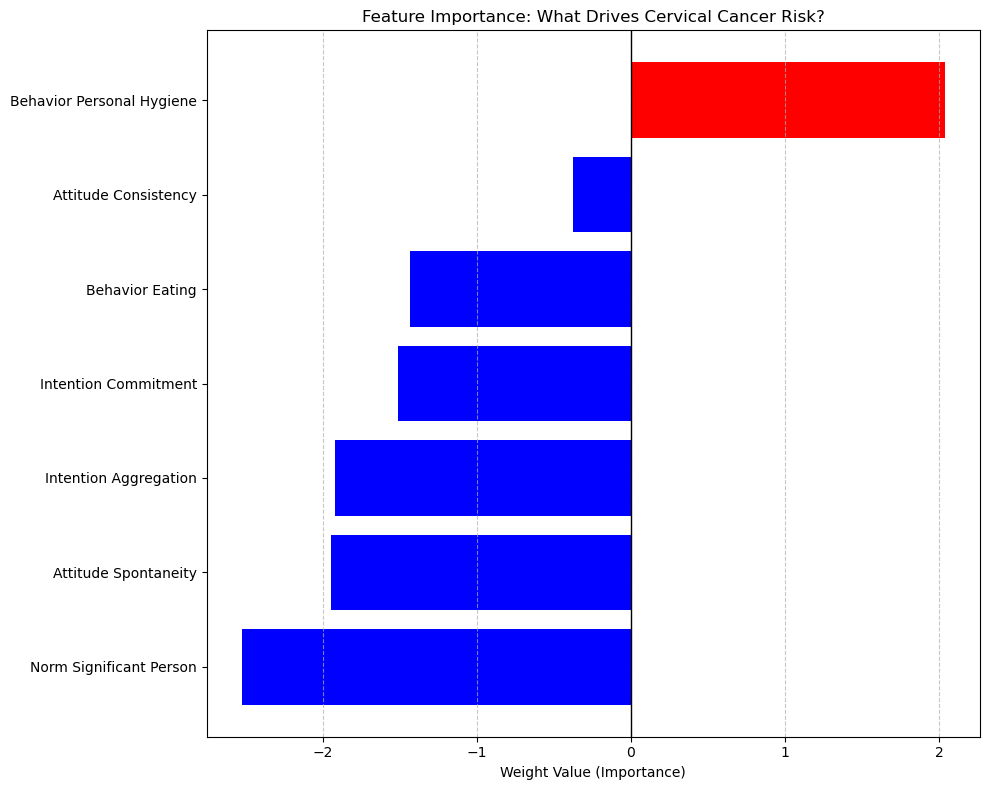

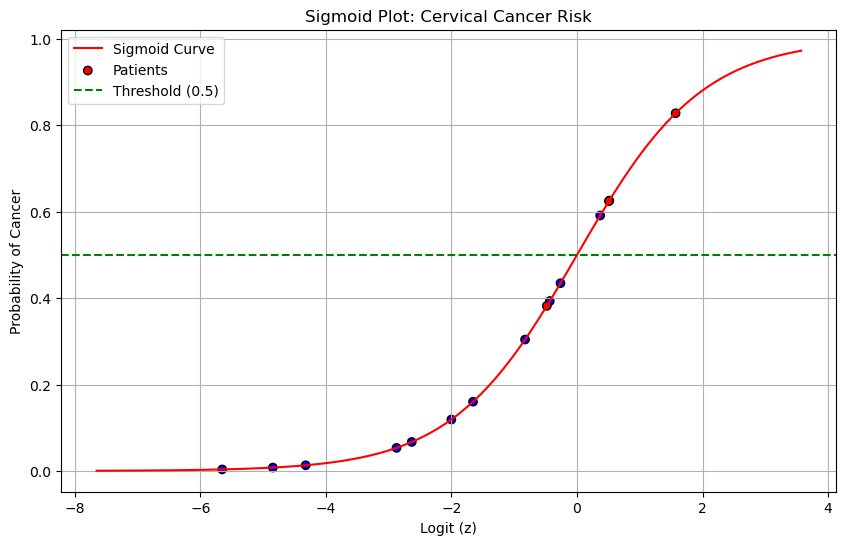

In [386]:
# Training Model
# --- Kodingan Versi Bersih ---

model = CustomLogisticRegression(learning_rate=0.1, epochs=1000)

# Cukup panggil fit SATU KALI
model.fit(X_train, y_train) 

# Ambil hasil prediksi
y_pred = model.predict(X_test)

# Ambil history loss dari dalam model untuk di-plot
history_loss = model.loss_history 

print("Training Process Finished")
print("Training Process Finished ")
print("Model Guess Result on Testing Data:", y_pred)
print("Original Answer from Testing Data  :", y_test)
print("Model loss history (every 100 epochs):", model.loss_history)
feature_names = ["Behavior Eating", "Behavior Personal Hygiene", "Intention Aggregation", 
    "Intention Commitment", "Attitude Consistency", "Attitude Spontaneity", 
    "Norm Significant Person", "Norm Fulfillment", "Perception Vulnerability", 
    "Perception Severity", "Motivation Strength", "Motivation Willingness", 
    "Social Support Emotionality", "Social Support Appreciation", 
    "Social Support Instrumental", "Empowerment Knowledge", 
    "Empowerment Abilities", "Empowerment Desires"] # Sesuaikan urutannya
for name, w in zip(feature_names, model.weights):
    print(f"{name}: {w:.4f}")

# 1. Gabungkan nama fitur dengan bobotnya
feature_importance = list(zip(feature_names, model.weights))

# 2. Urutkan berdasarkan nilai bobot (dari terkecil ke terbesar)
feature_importance.sort(key=lambda x: x[1])

names = [f[0] for f in feature_importance]
weights = [f[1] for f in feature_importance]

# 3. Plotting Horizontal Bar Chart
plt.figure(figsize=(10, 8))
colors = ['red' if w > 0 else 'blue' for w in weights] # Merah buat risiko, Biru buat pelindung
plt.barh(names, weights, color=colors)

plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Garis tengah
plt.xlabel('Weight Value (Importance)')
plt.title('Feature Importance: What Drives Cervical Cancer Risk?')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#Plotting
z_values = []
probabilities = []

for i in range(len(X_test)):
    # Hitung z = w.x + b
    z = sum(X_test[i][j] * model.weights[j] for j in range(len(model.weights))) + model.bias
    z_values.append(z)
    probabilities.append(1 / (1 + np.exp(-z)))

x_curve = np.linspace(min(z_values)-2, max(z_values)+2, 100)
y_curve = [1 / (1 + np.exp(-val)) for val in x_curve]

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_curve, y_curve, color='red', label='Sigmoid Curve') # Garis merah
plt.scatter(z_values, probabilities, c=y_test, cmap='bwr', edgecolor='k', label='Patients') # Titik pasien

plt.axhline(y=0.5, color='green', linestyle='--', label='Threshold (0.5)')
plt.xlabel('Logit (z)')
plt.ylabel('Probability of Cancer')
plt.title('Sigmoid Plot: Cervical Cancer Risk')
plt.legend()
plt.grid(True)
plt.show()

# 5. Result Validation & Metrics

In [387]:
def evaluate_model(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)

    precision = TP / (TP + FP + 1e-9)

    recall = TP / (TP + FN + 1e-9)
    
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-9)

    print("--- Evalution Model Raport ---")
    print(f"Accuracy  : {accuracy * 100:.2f}%")
    print(f"Precision   : {precision * 100:.2f}%")
    print(f"Recall    : {recall * 100:.2f}%")
    print(f"F1-Score  : {f1_score * 100:.2f}%")
    print("\n--- Confusion Matrix ---")
    print(f"True Positive (Sakit ditebak Sakit)   : {TP}")
    print(f"True Negative (Sehat ditebak Sehat)   : {TN}")
    print(f"False Positive (Sehat ditebak Sakit)  : {FP} (Alarm Palsu!)")
    print(f"False Negative (Sakit ditebak Sehat)  : {FN} (Bahaya, pasien lolos!)")
    
    return accuracy, precision, recall

# Memanggil fungsi menggunakan data tebakan (y_pred) dan kunci jawaban asli (y_test)
acc, prec, rec = evaluate_model(y_test, y_pred)

--- Evalution Model Raport ---
Accuracy  : 86.67%
Precision   : 75.00%
Recall    : 75.00%
F1-Score  : 75.00%

--- Confusion Matrix ---
True Positive (Sakit ditebak Sakit)   : 3
True Negative (Sehat ditebak Sehat)   : 10
False Positive (Sehat ditebak Sakit)  : 1 (Alarm Palsu!)
False Negative (Sakit ditebak Sehat)  : 1 (Bahaya, pasien lolos!)
